In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
print(os.getcwd())

sns.set_theme(font_scale=0.7, style="white")

from itertools import groupby

sys.path.append("..")
from src.features import compute_chromagram
from src.visualization import plot_chromagram, plot_chord_similarity
from src.templates import generate_chord_templates, get_chord_labels, VOCAB_CLASSICAL, REFERENCE_ROOT_AB, REFERENCE_ROOT_C
from src.recognition import recognize_template

/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks


In [2]:
audio_path = "../data/audio/chopin_etude_op25_no01_snippet.m4a"

# Match the FMP reference: scale n_fft while keeping hop_length fixed.
# At sample_rate=22050, these are roughly 93 ms / 372 ms / 1486 ms windows.
variant = "IIR"
sample_rate = 22050
hop_length = 1024
n_fft_values = 2048 * np.array([2, 16, 32])

for n_fft in n_fft_values:
    print(f"n_fft={n_fft:>5d}  window={n_fft / sample_rate * 1000:7.1f} ms")

n_fft= 4096  window=  185.8 ms
n_fft=32768  window= 1486.1 ms
n_fft=65536  window= 2972.2 ms


In [4]:
results = {}
for n_fft in n_fft_values:
    chroma = compute_chromagram(
        audio_path=audio_path,
        variant=variant,
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
    )
    recog = recognize_template(
        chroma=chroma,
        use_flats=True,
        vocab=VOCAB_CLASSICAL,
        reference_root=REFERENCE_ROOT_C,
        feature_rate=chroma.feature_rate,
    )
    results[n_fft] = (chroma, recog)

/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks/../src/features.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sample_rate = librosa.load(audio_path, sr=sample_rate)
/opt/homebrew/Caskroom/miniforge/base/envs/fmp_chord_recognition_env/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


(12, 590)


/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks/../src/features.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sample_rate = librosa.load(audio_path, sr=sample_rate)
/opt/homebrew/Caskroom/miniforge/base/envs/fmp_chord_recognition_env/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


(12, 590)
(12, 590)


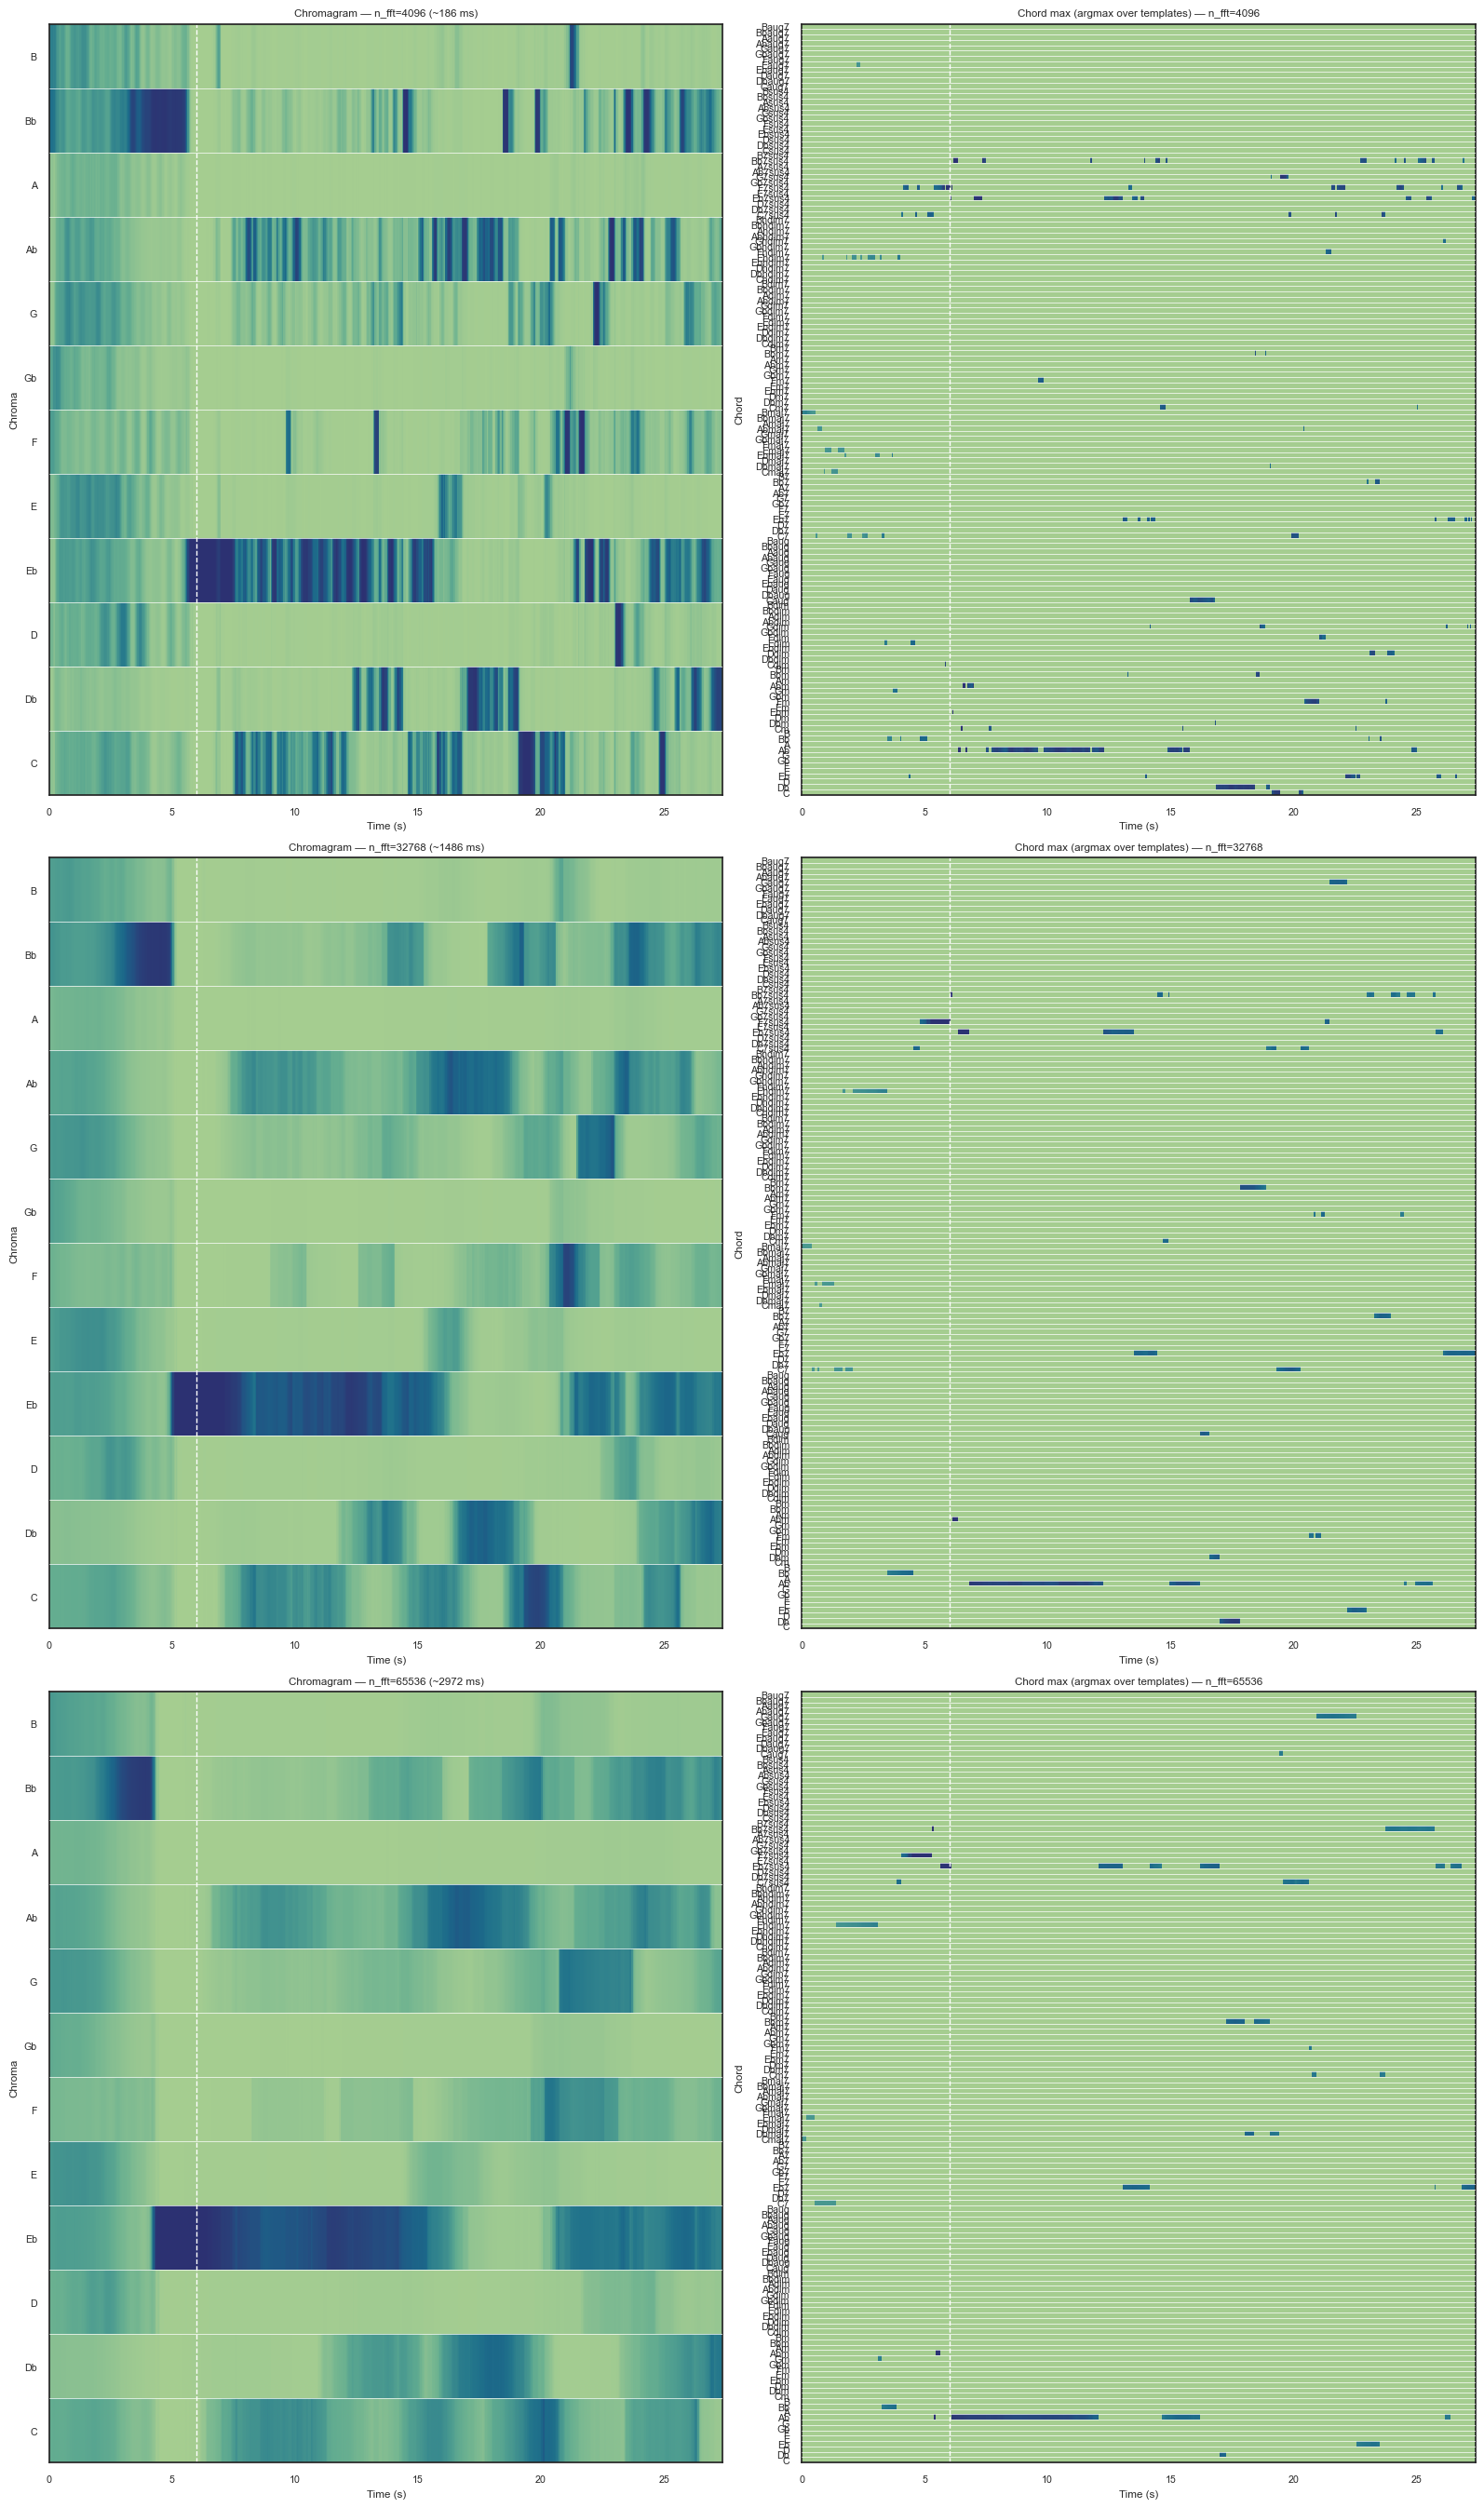

In [5]:
fig, axs = plt.subplots(len(n_fft_values), 2, figsize=(16, 9 * len(n_fft_values)),
                        gridspec_kw={"width_ratios": [1, 1]})
for i, n_fft in enumerate(n_fft_values):
    chroma, recog = results[n_fft]
    window_ms = n_fft / sample_rate * 1000
    plot_chromagram(
        X=chroma.X,
        feature_rate=chroma.feature_rate,
        ax=axs[i, 0],
        use_flats=True,
        reference_root=REFERENCE_ROOT_C,
        title=f"Chromagram — n_fft={n_fft} (~{window_ms:.0f} ms)",
    )
    axs[i, 0].axvline(6, color="white", linestyle="--", linewidth=1, label="Annotation start")
    plot_chord_similarity(
        chord_sim=recog.chord_max,
        feature_rate=chroma.feature_rate,
        ax=axs[i, 1],
        use_flats=True,
        title=f"Chord max (argmax over templates) — n_fft={n_fft}",
    )
    axs[i, 1].axvline(6, color="white", linestyle="--", linewidth=1, label="Annotation start")
fig.tight_layout()

In [6]:
# show chord progression starting at the 6s mark (actual piano start after some noise)
# TODO: filter that noise part out in the future. I can clean that up manually like I did for the snippet, 
# but would be nice to see it here as a reminder that it should be dealt with, ideally algorithmically,
# like with some sort of signal-to-noise ratio thresholding.

actual_start_seconds = 6
for n_fft in n_fft_values:
    chroma, recog = results[n_fft]
    start = int(actual_start_seconds * chroma.feature_rate)
    arr = recog.chord_indices[start:]
    
    change = np.concatenate(([0], np.where(np.diff(arr) != 0)[0] + 1))
    labels = [recog.labels[arr[i]] for i in change]
    times = (change + start) / chroma.feature_rate
    
    progression = list(zip(times, labels))
    print(f"\nn_fft={n_fft}  ({len(progression)} segments)")
    for t, label in progression:
        print(f"  {t:6.2f}s  {label}")



n_fft=4096  (95 segments)
    5.99s  F7sus4
    6.04s  Eb7sus4
    6.08s  F7sus4
    6.13s  Ebm
    6.18s  Bb7sus4
    6.36s  Ab
    6.46s  Cm
    6.55s  Abm
    6.64s  Ab
    6.73s  Abm
    7.01s  Eb7sus4
    7.34s  Bb7sus4
    7.48s  Ab
    7.62s  Cm
    7.71s  Ab
    9.61s  Fm7
    9.85s  Ab
   11.75s  Bb7sus4
   11.80s  Ab
   12.31s  Eb7sus4
   13.05s  Eb7
   13.24s  Bbm
   13.28s  F7sus4
   13.42s  Eb7sus4
   13.65s  Eb7
   13.79s  Eb7sus4
   13.93s  Bb7sus4
   13.98s  Eb
   14.02s  Eb7
   14.16s  Gdim
   14.21s  Eb7
   14.40s  Bb7sus4
   14.58s  Cm7
   14.81s  Bb7sus4
   14.86s  Ab
   15.46s  Cm
   15.51s  Ab
   15.79s  Caug
   16.81s  Dbm
   16.86s  Db
   18.44s  Bbm7
   18.48s  Bbm
   18.62s  Gdim
   18.85s  Bbm7
   18.90s  Db
   19.04s  Dbmaj7
   19.09s  G7sus4
   19.13s  C
   19.46s  G7sus4
   19.78s  C7sus4
   19.92s  C7
   20.20s  C
   20.39s  Abmaj7
   20.43s  Fm
   21.04s  Fdim
   21.32s  Fhdim7
   21.55s  F7sus4
   21.69s  C7sus4
   21.78s  F7sus4
   22.11s  Eb
   22.52

In [7]:
# load my own annotations on the piece
annot_chord_progression = pd.read_csv("../data/annotations/chopin_etude_op25_no01_snippet.csv")
annot_chord_progression["timestamp"] = pd.to_datetime(annot_chord_progression["timestamp"], unit="s")
annot_chord_progression

,timestamp,chord
0,2026-05-28 00:00:07,Ab
1,2026-05-28 00:00:12,Eb7
2,2026-05-28 00:00:15,Ab
3,2026-05-28 00:00:16,Caug
4,2026-05-28 00:00:17,Db
5,2026-05-28 00:00:19,C
6,2026-05-28 00:00:20,Fm
7,2026-05-28 00:00:21,Fhdim7
8,2026-05-28 00:00:22,F7sus4
9,2026-05-28 00:00:23,Bbaug


Notes on actual evaluation, which I still have to think/read about:
1. The first note is a single E-flat from the melodic line, so the similarities are likely distributed across multiple chords, and the first predicted chord of Ebm is understandable, but wrong. The actual first chord is Ab major.
2. misclassified arpeggiated chords. the variables I will need to play around with are the window size, and using some threshold instead of getting the chord with max. similarity. Window size can be manually determined, but ideally should be some function of time between beats, perhaps. But even with the correct window size, misclassifications could be due to chord inversions with some note removed, or added from the melodic line. It will then be helpful to see the other probable chords to proceed with performance evaluation.

To-do's:
- timestamps have now been added to the predicted chord progressions and annotated chord progressions. merging on timestamp to be done next - could be an outer join with fill-forward in the annotations since there are more changes in chords in the predictions, or i can merge on the nearest, earlier annotation timestamp with some aggregation. 
- improve chord similarity plot for the expanded vocabulary